In [1]:
import pandas as pd

df = pd.read_csv("../data/medical_questions.csv")

print(df.head())
print("\nDataset size:", df.shape)
print("\nColumns:", df.columns.tolist())

     id                                           question          category
0  F001     How do I begin the medical submission process?  PROCESS_GUIDANCE
1  F002  What steps should I follow to submit my medica...  PROCESS_GUIDANCE
2  F003  How can I complete the medical submission proc...  PROCESS_GUIDANCE
3  F004  What is the procedure for submitting a medical...  PROCESS_GUIDANCE
4  F005  Where should I start if I need to submit a med...  PROCESS_GUIDANCE

Dataset size: (201, 3)

Columns: ['id', 'question', 'category']


In [2]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate questions:")
print(df["question"].duplicated().sum())

print("\nCategory counts:")
print(df["category"].value_counts())



Missing values:
id          0
question    0
category    0
dtype: int64

Duplicate questions:
48

Category counts:
category
REFERENCE_NUMBER_HELP    41
PROCESS_GUIDANCE         40
DOCUMENT_REQUIREMENTS    40
MA_SUBMISSION_HELP       40
OUT_OF_SCOPE             40
Name: count, dtype: int64


In [3]:
# Keep only the required columns
df = df[["question", "category"]].copy()

# Remove missing values
df = df.dropna(subset=["question", "category"])

# Remove extra spaces
df["question"] = df["question"].str.strip()
df["category"] = df["category"].str.strip().str.upper()

# Remove empty questions
df = df[df["question"] != ""]

# Remove duplicate questions
df = df.drop_duplicates(subset=["question"])

# Reset row numbers
df = df.reset_index(drop=True)

print("Cleaned dataset size:", df.shape)
print("\nCategory counts:")
print(df["category"].value_counts())

Cleaned dataset size: (153, 2)

Category counts:
category
PROCESS_GUIDANCE         31
DOCUMENT_REQUIREMENTS    31
OUT_OF_SCOPE             31
REFERENCE_NUMBER_HELP    30
MA_SUBMISSION_HELP       30
Name: count, dtype: int64


In [4]:
expected_categories = {
    "PROCESS_GUIDANCE",
    "REFERENCE_NUMBER_HELP",
    "DOCUMENT_REQUIREMENTS",
    "MA_SUBMISSION_HELP",
    "OUT_OF_SCOPE"
}

actual_categories = set(df["category"].unique())

print("Categories found:")
print(actual_categories)

unexpected_categories = actual_categories - expected_categories

if unexpected_categories:
    print("\nIncorrect categories found:")
    print(unexpected_categories)
else:
    print("\nAll category names are correct.")

Categories found:
{'MA_SUBMISSION_HELP', 'DOCUMENT_REQUIREMENTS', 'OUT_OF_SCOPE', 'PROCESS_GUIDANCE', 'REFERENCE_NUMBER_HELP'}

All category names are correct.


In [5]:
X = df["question"]
y = df["category"]


print("Number of questions:", len(X))
print("Number of categories:", y.nunique())

Number of questions: 153
Number of categories: 5


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training questions:", len(X_train))
print("Testing questions:", len(X_test))


Training questions: 122
Testing questions: 31


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=1
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=42
        )
    )
])

print("Model pipeline created successfully.")

Model pipeline created successfully.


In [8]:
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


In [9]:
y_pred = model.predict(X_test)

print("Predictions completed.")
print(y_pred[:10])


Predictions completed.
['DOCUMENT_REQUIREMENTS' 'PROCESS_GUIDANCE' 'REFERENCE_NUMBER_HELP'
 'REFERENCE_NUMBER_HELP' 'OUT_OF_SCOPE' 'MA_SUBMISSION_HELP'
 'PROCESS_GUIDANCE' 'OUT_OF_SCOPE' 'MA_SUBMISSION_HELP'
 'DOCUMENT_REQUIREMENTS']


In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model accuracy:", accuracy)
print("Accuracy percentage:", round(accuracy * 100, 2), "%")

Model accuracy: 0.8709677419354839
Accuracy percentage: 87.1 %


In [11]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

                       precision    recall  f1-score   support

DOCUMENT_REQUIREMENTS       0.78      1.00      0.88         7
   MA_SUBMISSION_HELP       1.00      1.00      1.00         6
         OUT_OF_SCOPE       1.00      0.50      0.67         6
     PROCESS_GUIDANCE       0.71      0.83      0.77         6
REFERENCE_NUMBER_HELP       1.00      1.00      1.00         6

             accuracy                           0.87        31
            macro avg       0.90      0.87      0.86        31
         weighted avg       0.89      0.87      0.86        31



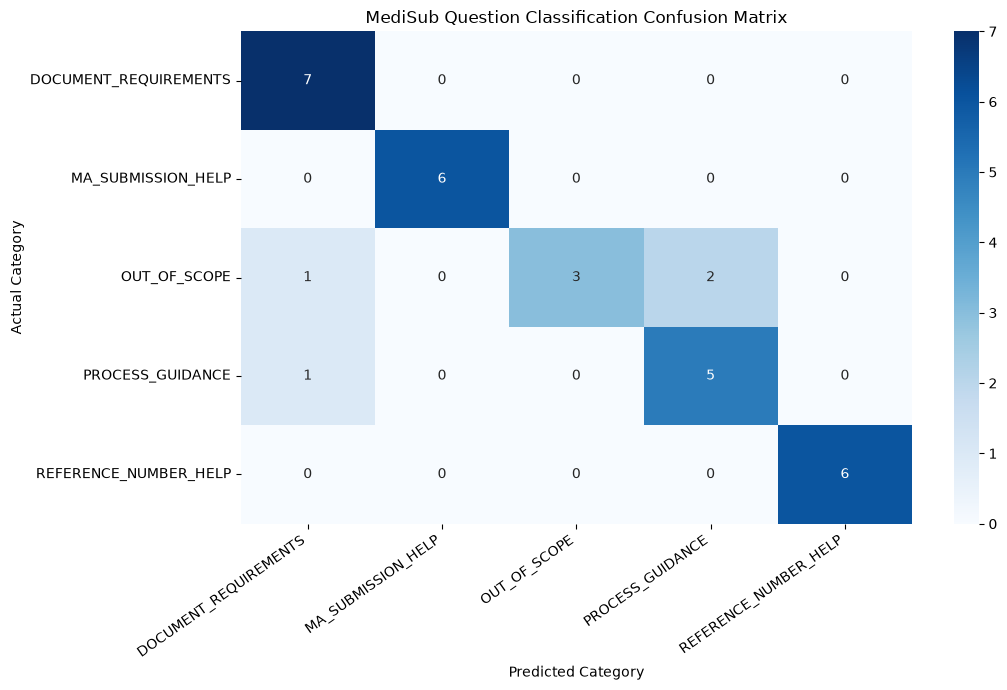

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

categories = sorted(y.unique())

matrix = confusion_matrix(
    y_test,
    y_pred,
    labels=categories
)

plt.figure(figsize=(11, 7))

sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=categories,
    yticklabels=categories
)

plt.title("MediSub Question Classification Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [13]:
test_questions = [
    "What documents should I submit?",
    "How do I obtain my medical reference number?",
    "Where should I submit my completed medical forms?",
    "What is the medical submission process?",
    "How can I change my Wi-Fi password?"
]

for question in test_questions:
    prediction = model.predict([question])[0]
    probabilities = model.predict_proba([question])[0]
    confidence = probabilities.max()

    print("Question:", question)
    print("Category:", prediction)
    print("Confidence:", round(confidence * 100, 2), "%")
    print("-" * 60)

Question: What documents should I submit?
Category: DOCUMENT_REQUIREMENTS
Confidence: 34.42 %
------------------------------------------------------------
Question: How do I obtain my medical reference number?
Category: REFERENCE_NUMBER_HELP
Confidence: 64.43 %
------------------------------------------------------------
Question: Where should I submit my completed medical forms?
Category: MA_SUBMISSION_HELP
Confidence: 32.49 %
------------------------------------------------------------
Question: What is the medical submission process?
Category: PROCESS_GUIDANCE
Confidence: 60.62 %
------------------------------------------------------------
Question: How can I change my Wi-Fi password?
Category: PROCESS_GUIDANCE
Confidence: 28.22 %
------------------------------------------------------------


In [14]:
test_questions = [
    "What documents should I submit?",
    "How do I obtain my medical reference number?",
    "Where should I submit my completed medical forms?",
    "What is the medical submission process?",
    "How can I change my Wi-Fi password?"
]

for question in test_questions:
    prediction = model.predict([question])[0]
    probabilities = model.predict_proba([question])[0]
    confidence = probabilities.max()

    print("Question:", question)
    print("Category:", prediction)
    print("Confidence:", round(confidence * 100, 2), "%")
    print("-" * 60)

    

Question: What documents should I submit?
Category: DOCUMENT_REQUIREMENTS
Confidence: 34.42 %
------------------------------------------------------------
Question: How do I obtain my medical reference number?
Category: REFERENCE_NUMBER_HELP
Confidence: 64.43 %
------------------------------------------------------------
Question: Where should I submit my completed medical forms?
Category: MA_SUBMISSION_HELP
Confidence: 32.49 %
------------------------------------------------------------
Question: What is the medical submission process?
Category: PROCESS_GUIDANCE
Confidence: 60.62 %
------------------------------------------------------------
Question: How can I change my Wi-Fi password?
Category: PROCESS_GUIDANCE
Confidence: 28.22 %
------------------------------------------------------------


In [15]:
from pathlib import Path
import joblib

models_folder = Path("../models")
models_folder.mkdir(exist_ok=True)

model_path = models_folder / "medical_classifier.joblib"

joblib.dump(model, model_path)

print("Model saved successfully:")
print(model_path)

Model saved successfully:
..\models\medical_classifier.joblib
